In [1]:
import os
import numpy as np
import uproot
import awkward as ak
import matplotlib.pyplot as plt


In [2]:
# ---- File & variables ----
root_path = "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/00012345_00006789_1.DATA.root"

# Expected branches
BR_B_MASS   = "lab0_MASS"
BR_PIDK     = "lab1_PIDK"
BR_D_MASS   = "lab2_MASS"

# Plot output filenames (PNG, suitable for GitLab MR)
OUT_B_MASS  = "B_mass_PIDK_cuts.png"
OUT_PIDK    = "PIDK_hist.png"
OUT_D_MASS  = "D_mass.png"

# ---- Plot aesthetics ----
plt.rcParams.update({
    "figure.figsize": (7.0, 5.0),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 12
})

# Binning / ranges (auto if None)
B_BINS   = 80
B_RANGE  = None        # None -> from percentiles; set (5000, 5600) MeV/c^2 to fix
PIDK_BINS  = 60
PIDK_RANGE = (0, None) # start at 0, auto upper bound
D_BINS   = 80
D_RANGE  = None        # e.g. (1800, 1940)


In [3]:
# Open ROOT file
file = uproot.open(root_path)

# Try to find a tree containing the expected branches
candidate_trees = []
for k, obj in file.items():
    if not isinstance(obj, uproot.behaviors.TTree.TTree):
        continue
    branches = set(obj.keys())
    needed = {BR_B_MASS, BR_PIDK, BR_D_MASS}
    if needed.issubset(branches):
        candidate_trees.append(obj)

if not candidate_trees:
    # fall back: pick the first tree that at least has BR_PIDK
    for k, obj in file.items():
        if isinstance(obj, uproot.behaviors.TTree.TTree) and BR_PIDK in obj.keys():
            candidate_trees.append(obj)
            break

if not candidate_trees:
    raise RuntimeError("No suitable TTree found with the required branches.")

tree = candidate_trees[0]
print(f"Using tree: {tree.title or next(iter(file.keys()))}")
print("Branches in tree include:", ", ".join(list(tree.keys())[:12]), "...")


Using tree: DecayTree
Branches in tree include: totCandidates, nCandidate, EVENTNUMBER, Hlt1TrackMVADecision, Hlt1TwoTrackMVADecision, Hlt1_TCK, Hlt2B2OC_BdToDmK_DmToPimPimKpDecision, Hlt2Topo2BodyDecision, Hlt2Topo3BodyDecision, Hlt2_TCK, RUNNUMBER, nFTClusters ...




In [4]:
needed = [BR_B_MASS, BR_PIDK, BR_D_MASS]
arrs = tree.arrays(expressions=needed, library="ak")

b_mass = ak.to_numpy(arrs[BR_B_MASS])
pidk   = ak.to_numpy(arrs[BR_PIDK])
d_mass = ak.to_numpy(arrs[BR_D_MASS])

# Drop NaNs/Infs just in case
def clean(x):
    x = np.asarray(x)
    return x[np.isfinite(x)]
b_mass = clean(b_mass)
pidk   = clean(pidk)
d_mass = clean(d_mass)

print(f"Loaded: B entries={b_mass.size}, PIDK entries={pidk.size}, D entries={d_mass.size}")


Loaded: B entries=3133, PIDK entries=3133, D entries=3133




In [5]:
def percentile_range(x, lo=None, hi=None, pad=0.02):
    """Range from the 0.5th and 99.5th percentiles, with a little padding, unless lo/hi are given."""
    x = np.asarray(x)
    if lo is None:
        lo = np.quantile(x, 0.005)
    if hi is None:
        hi = np.quantile(x, 0.995)
    span = hi - lo
    return (lo - pad*span, hi + pad*span)


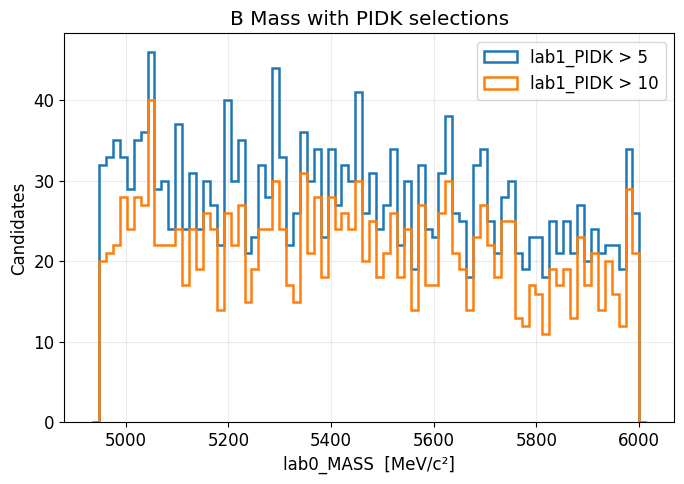

Saved: B_mass_PIDK_cuts.png




In [6]:
mask_5  = pidk > 5
mask_10 = pidk > 10

b_range = B_RANGE if B_RANGE is not None else percentile_range(b_mass)

plt.figure()
plt.hist(b_mass[mask_5],  bins=B_BINS, range=b_range, histtype="step", linewidth=1.8, label="lab1_PIDK > 5")
plt.hist(b_mass[mask_10], bins=B_BINS, range=b_range, histtype="step", linewidth=1.8, label="lab1_PIDK > 10")

plt.xlabel("lab0_MASS  [MeV/c²]")
plt.ylabel("Candidates")
plt.title("B Mass with PIDK selections")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_B_MASS, dpi=150)
plt.show()

print(f"Saved: {OUT_B_MASS}")


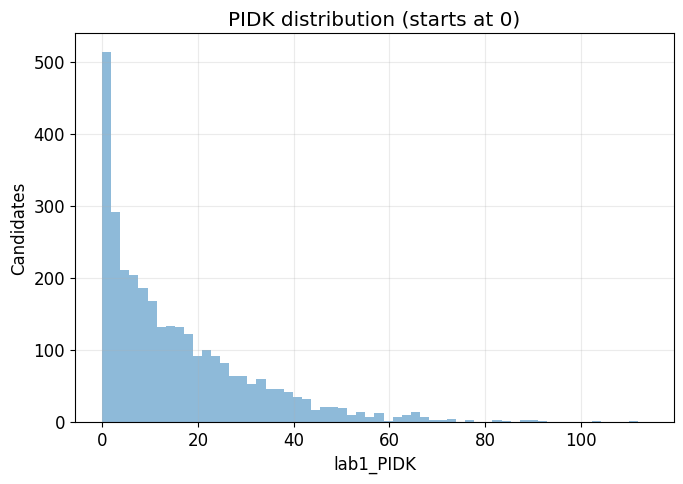

Saved: PIDK_hist.png




In [7]:
# Upper bound from the 99.7th percentile when none is given
if PIDK_RANGE[1] is None:
    hi = float(np.quantile(pidk, 0.997)) if pidk.size else 10.0
    pidk_range = (PIDK_RANGE[0], hi)
else:
    pidk_range = PIDK_RANGE

plt.figure()
plt.hist(pidk, bins=PIDK_BINS, range=pidk_range, histtype="stepfilled", alpha=0.5)
plt.xlabel("lab1_PIDK")
plt.ylabel("Candidates")
plt.title("PIDK distribution (starts at 0)")
plt.tight_layout()
plt.savefig(OUT_PIDK, dpi=150)
plt.show()

print(f"Saved: {OUT_PIDK}")


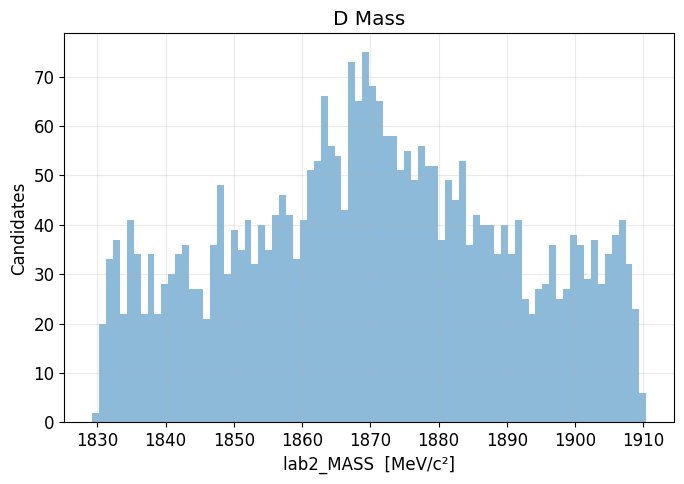

Saved: D_mass.png




In [8]:
d_range = D_RANGE if D_RANGE is not None else percentile_range(d_mass)

plt.figure()
plt.hist(d_mass, bins=D_BINS, range=d_range, histtype="stepfilled", alpha=0.5)
plt.xlabel("lab2_MASS  [MeV/c²]")
plt.ylabel("Candidates")
plt.title("D Mass")
plt.tight_layout()
plt.savefig(OUT_D_MASS, dpi=150)
plt.show()

print(f"Saved: {OUT_D_MASS}")


# unbinned

In [7]:

import numpy as np
import matplotlib.pyplot as plt
import uproot, awkward as ak
from scipy.stats import gaussian_kde


In [8]:
# Input file
root_path = "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/00012345_00006789_1.DATA.root"

# Branch names
BR_B_MASS = "lab0_MASS"
BR_PIDK   = "lab1_PIDK"
BR_D_MASS = "lab2_MASS"

# Output images
OUT_B = "B_mass_unbinned_PIDK.png"
OUT_P = "PIDK_unbinned.png"
OUT_D = "D_mass_unbinned.png"

# Matplotlib look
plt.rcParams.update({
    "figure.figsize": (7.2, 5.0),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 12
})


In [9]:
f = uproot.open(root_path)

tree = None
needed = {BR_B_MASS, BR_PIDK, BR_D_MASS}
for _, obj in f.items():
    if isinstance(obj, uproot.behaviors.TTree.TTree) and needed.issubset(set(obj.keys())):
        tree = obj
        break
if tree is None:
    raise RuntimeError("No TTree found with required branches.")

arrs = tree.arrays([BR_B_MASS, BR_PIDK, BR_D_MASS], library="ak")

def clean(x):
    x = np.asarray(ak.to_numpy(x))
    return x[np.isfinite(x)]

b_mass = clean(arrs[BR_B_MASS])
pidk   = clean(arrs[BR_PIDK])
d_mass = clean(arrs[BR_D_MASS])

print(f"Entries — B: {b_mass.size}, PIDK: {pidk.size}, D: {d_mass.size}")


Entries — B: 3133, PIDK: 3133, D: 3133




In [10]:
def kde_curve(x, xmin=None, xmax=None, points=600, bw="scott"):
    x = np.asarray(x)
    if len(x) == 0:
        raise ValueError("Empty array passed to kde_curve()")
    if xmin is None:
        xmin = np.quantile(x, 0.005)
    if xmax is None:
        xmax = np.quantile(x, 0.995)
    grid = np.linspace(xmin, xmax, points)
    kde  = gaussian_kde(x, bw_method=bw)
    return grid, kde(grid)

def rugplot(x, ax=None, height=0.02, alpha=0.25, thin_max=400):
    ax = ax or plt.gca()
    x = np.asarray(x)
    ymin, ymax = ax.get_ylim()
    h = (ymax - ymin) * height
    step = max(1, len(x)//thin_max)
    for xi in x[::step]:
        ax.vlines(xi, ymin, ymin + h, alpha=alpha, linewidth=0.7)


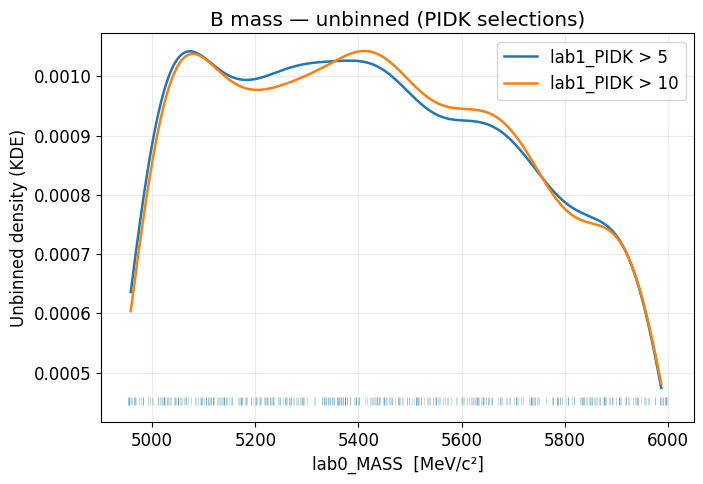

Saved: B_mass_unbinned_PIDK.png




In [11]:
mask5  = pidk > 5
mask10 = pidk > 10

# Common plotting window from the 1st-99th percentiles of the full B mass sample
b_lo = float(np.quantile(b_mass, 0.01))
b_hi = float(np.quantile(b_mass, 0.99))

g5_x,  g5_y  = kde_curve(b_mass[mask5],  b_lo, b_hi)
g10_x, g10_y = kde_curve(b_mass[mask10], b_lo, b_hi)

plt.figure()
plt.plot(g5_x,  g5_y,  label="lab1_PIDK > 5",  linewidth=1.8)
plt.plot(g10_x, g10_y, label="lab1_PIDK > 10", linewidth=1.8)
rugplot(b_mass[mask5])
plt.xlabel("lab0_MASS  [MeV/c²]")
plt.ylabel("Unbinned density (KDE)")
plt.title("B mass — unbinned (PIDK selections)")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_B, dpi=150)
plt.show()

print(f"Saved: {OUT_B}")


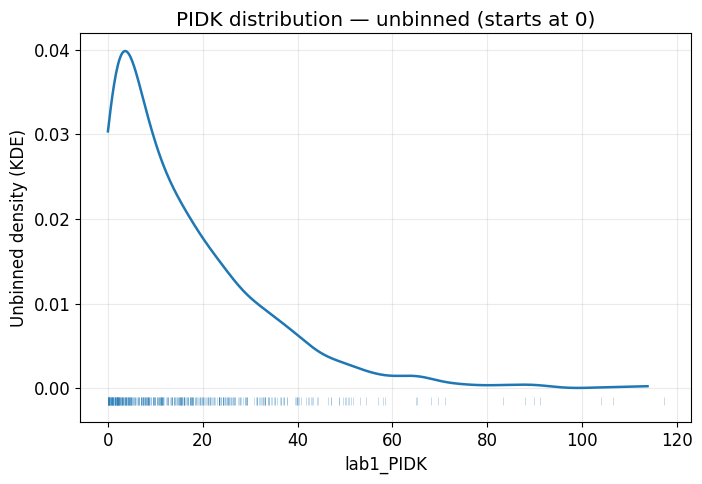

Saved: PIDK_unbinned.png




In [12]:
# PIDK below zero carries no information for this check; clip at 0 so the axis starts there
pidk_nonneg = pidk[pidk >= 0]

# Upper bound from a high percentile for a stable view
p_hi = float(np.quantile(pidk_nonneg, 0.997)) if pidk_nonneg.size else 10.0
gx, gy = kde_curve(pidk_nonneg, xmin=0.0, xmax=p_hi)

plt.figure()
plt.plot(gx, gy, linewidth=1.8)
rugplot(pidk_nonneg)
plt.xlabel("lab1_PIDK")
plt.ylabel("Unbinned density (KDE)")
plt.title("PIDK distribution — unbinned (starts at 0)")
plt.tight_layout()
plt.savefig(OUT_P, dpi=150)
plt.show()

print(f"Saved: {OUT_P}")


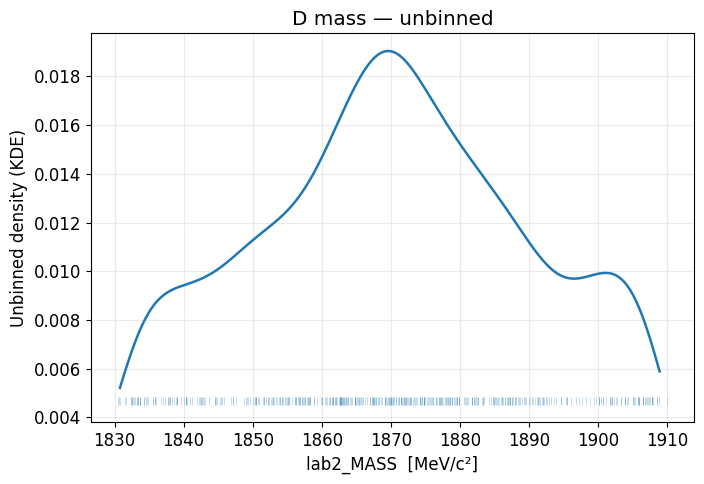

Saved: D_mass_unbinned.png




In [13]:
# Fixed D window when the masses are in MeV; otherwise fall back to percentiles
if 1750 < np.median(d_mass) < 1950:
    d_view = d_mass[(d_mass > 1800) & (d_mass < 1940)]
else:
    lo = float(np.quantile(d_mass, 0.01))
    hi = float(np.quantile(d_mass, 0.99))
    d_view = d_mass[(d_mass > lo) & (d_mass < hi)]

gx, gy = kde_curve(d_view)

plt.figure()
plt.plot(gx, gy, linewidth=1.8, label="KDE (unbinned)")
rugplot(d_view)
plt.xlabel("lab2_MASS  [MeV/c²]")
plt.ylabel("Unbinned density (KDE)")
plt.title("D mass — unbinned")
plt.tight_layout()
plt.savefig(OUT_D, dpi=150)
plt.show()

print(f"Saved: {OUT_D}")


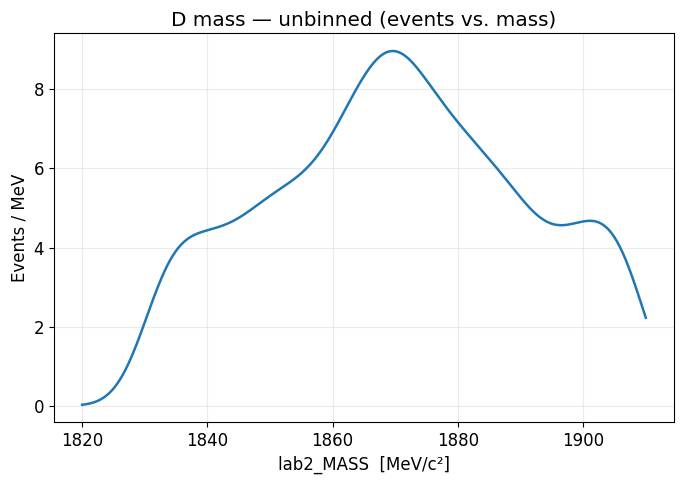

In [14]:
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt

# d_view is the D-mass selection made above
gx = np.linspace(1820, 1910, 600)
kde = gaussian_kde(d_view, bw_method="scott")

# Scale KDE by total number of events and spacing (approximate events/MeV)
dx = gx[1] - gx[0]
gy = kde(gx) * len(d_view) * dx

plt.figure(figsize=(7,5))
plt.plot(gx, gy, linewidth=1.8, color="C0")
# rug ticks marking individual candidates
# for xi in d_view[::max(1, len(d_view)//400)]:
#     plt.vlines(xi, 0, max(gy)*0.05, color="C0", alpha=0.2, linewidth=0.7)

plt.xlabel("lab2_MASS  [MeV/c²]")
plt.ylabel("Events / MeV")
plt.title("D mass — unbinned (events vs. mass)")
plt.tight_layout()
plt.show()


In [16]:
print(f"Total events in file: {len(b_mass)}")
print(f"B mass entries: {len(b_mass)}")
print(f"PIDK entries: {len(pidk)}")
print(f"D mass entries: {len(d_mass)}")


Total events in file: 3133
B mass entries: 3133
PIDK entries: 3133
D mass entries: 3133




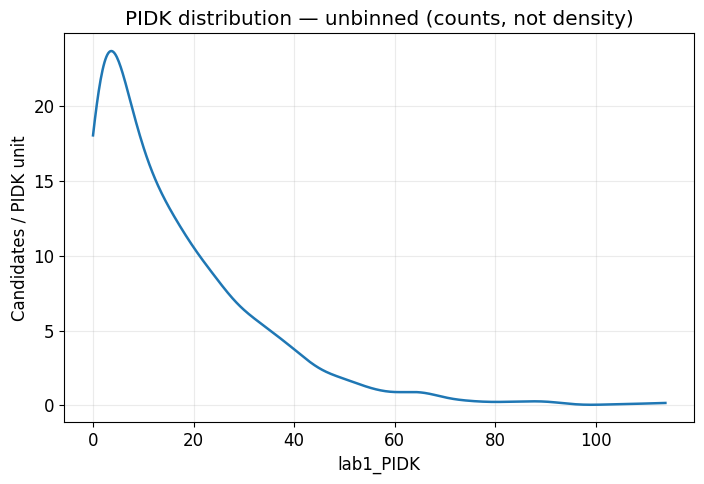

Total candidates (PIDK >= 0): 3133




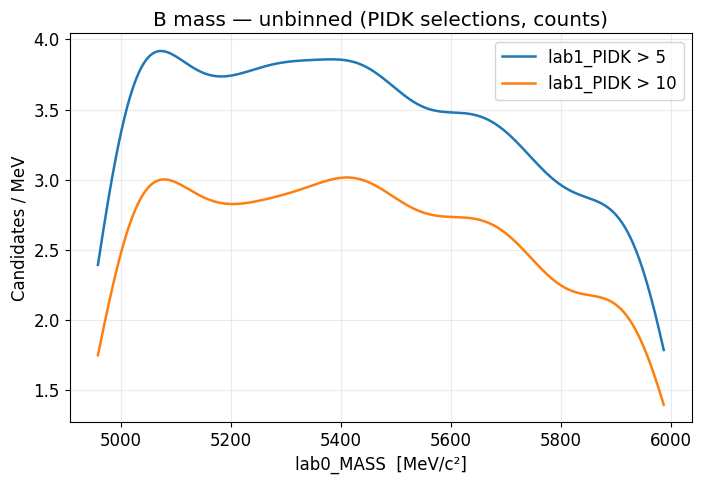

Candidates with PIDK>5 : 2189
Candidates with PIDK>10: 1684




In [17]:


# --- config ---
root_path = "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/00012345_00006789_1.DATA.root"
BR_B_MASS, BR_PIDK, BR_D_MASS = "lab0_MASS", "lab1_PIDK", "lab2_MASS"

plt.rcParams.update({
    "figure.figsize": (7.2, 5.0),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 12
})

# --- load arrays (auto-pick a TTree with required branches) ---
f = uproot.open(root_path)
tree = None
need = {BR_B_MASS, BR_PIDK, BR_D_MASS}
for _, obj in f.items():
    if isinstance(obj, uproot.behaviors.TTree.TTree) and need.issubset(set(obj.keys())):
        tree = obj
        break
if tree is None:
    raise RuntimeError("No TTree found with required branches.")

arr = tree.arrays([BR_B_MASS, BR_PIDK, BR_D_MASS], library="ak")
clean = lambda x: np.asarray(ak.to_numpy(x))[np.isfinite(ak.to_numpy(x))]
b_mass = clean(arr[BR_B_MASS])
pidk   = clean(arr[BR_PIDK])

# --- helpers: KDE scaled to counts (not probability density) ---
def kde_events(x, xmin, xmax, points=600, bw="scott"):
    """
    Returns grid xg and curve yg where yg approximates *events per unit of x*.
    We scale the PDF by N * dx so the y-axis is in candidates per unit-x.
    """
    x = np.asarray(x)
    if x.size == 0:
        return np.array([0.0, 1.0]), np.array([0.0, 0.0])
    xg = np.linspace(xmin, xmax, points)
    dx = xg[1] - xg[0]
    kde = gaussian_kde(x, bw_method=bw)
    yg = kde(xg) * len(x) * dx   # <-- scale to candidates / (unit x)
    return xg, yg

# ============================================================
# 1) PIDK distribution — y-axis in candidates (events per PIDK unit)
# ============================================================
pidk_nonneg = pidk[pidk >= 0]
if pidk_nonneg.size == 0:
    raise RuntimeError("No non-negative PIDK values to plot.")

p_lo = 0.0
p_hi = float(np.quantile(pidk_nonneg, 0.997))  # stable upper bound

gx, gy = kde_events(pidk_nonneg, p_lo, p_hi)

plt.figure()
plt.plot(gx, gy, linewidth=1.8)
plt.xlabel("lab1_PIDK")
plt.ylabel("Candidates / PIDK unit")
plt.title("PIDK distribution — unbinned (counts, not density)")
plt.tight_layout()
plt.savefig("PIDK_unbinned_counts.png", dpi=150)
plt.show()

print(f"Total candidates (PIDK >= 0): {len(pidk_nonneg)}")

# ============================================================
# 2) B mass with PIDK selections — y-axis in candidates (events per MeV)
# ============================================================
mask5  = pidk > 5
mask10 = pidk > 10

# Both curves share one B-mass window so they can be compared directly
b_lo = float(np.quantile(b_mass, 0.01))
b_hi = float(np.quantile(b_mass, 0.99))

g5_x,  g5_y  = kde_events(b_mass[mask5],  b_lo, b_hi)
g10_x, g10_y = kde_events(b_mass[mask10], b_lo, b_hi)

plt.figure()
plt.plot(g5_x,  g5_y,  label="lab1_PIDK > 5",  linewidth=1.8)
plt.plot(g10_x, g10_y, label="lab1_PIDK > 10", linewidth=1.8)
plt.xlabel("lab0_MASS  [MeV/c²]")
plt.ylabel("Candidates / MeV")
plt.title("B mass — unbinned (PIDK selections, counts)")
plt.legend()
plt.tight_layout()
plt.savefig("B_mass_unbinned_counts_PIDK.png", dpi=150)
plt.show()

print(f"Candidates with PIDK>5 : {int(mask5.sum())}")
print(f"Candidates with PIDK>10: {int(mask10.sum())}")


Entries — B: 3133, PIDK: 3133, D: 3133




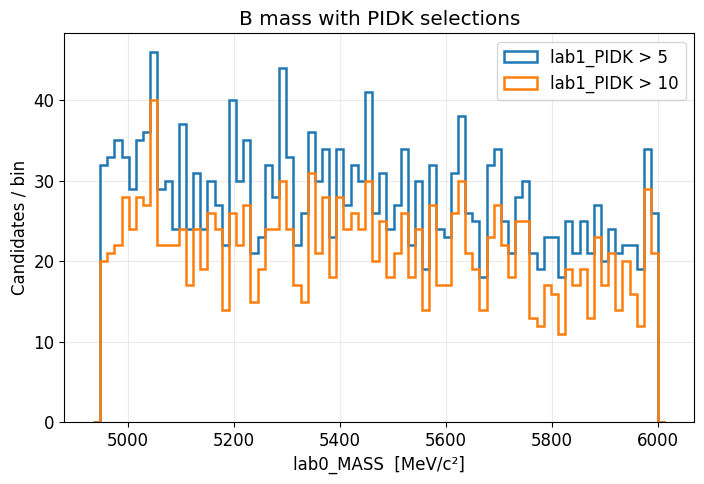

Saved: B_mass_hist_PIDKcuts.png
Candidates with PIDK>5 : 2189
Candidates with PIDK>10: 1684




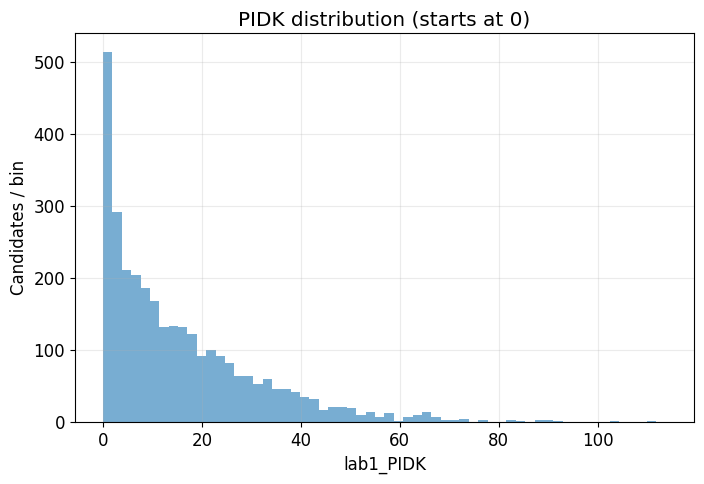

Saved: PIDK_hist.png
Candidates with PIDK >= 0: 3133




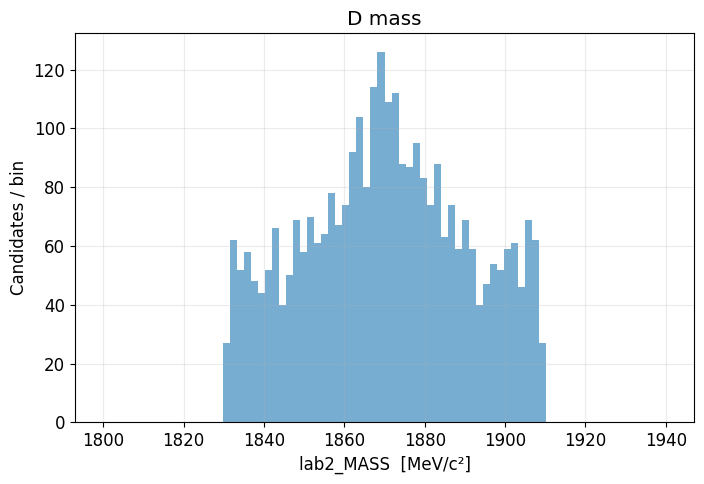

Saved: D_mass_hist.png




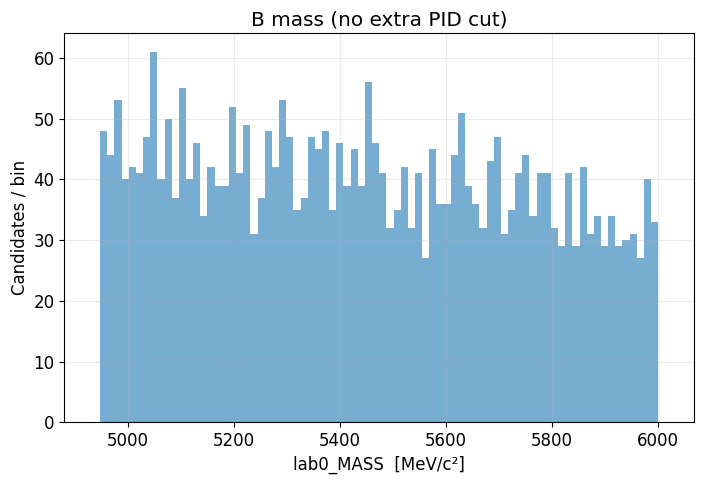

Saved: B_mass_hist_noPIDcut.png




In [18]:

import numpy as np
import matplotlib.pyplot as plt
import uproot, awkward as ak

# ---------- config ----------
root_path = "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/00012345_00006789_1.DATA.root"

BR_B_MASS = "lab0_MASS"
BR_PIDK   = "lab1_PIDK"
BR_D_MASS = "lab2_MASS"

# Output files
OUT_B_PIDK   = "B_mass_hist_PIDKcuts.png"
OUT_PIDK     = "PIDK_hist.png"
OUT_D        = "D_mass_hist.png"
OUT_B_NOSEL  = "B_mass_hist_noPIDcut.png"

# Plot look
plt.rcParams.update({
    "figure.figsize": (7.2, 5.0),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 12
})

# Binning and ranges
B_BINS   = 80
B_RANGE  = None        # None -> from percentiles; set (5000, 5600) MeV/c^2 to fix
PIDK_BINS  = 60
PIDK_RANGE = (0, None) # start at 0; upper auto-chosen
D_BINS   = 80
D_RANGE  = None        # e.g. (1800, 1940)

# ---------- helpers ----------
def clean(x):
    x = np.asarray(ak.to_numpy(x))
    return x[np.isfinite(x)]

def percentile_range(x, lo=None, hi=None, pad=0.02):
    """Range from the 0.5th and 99.5th percentiles, with a little padding, unless lo/hi are given."""
    x = np.asarray(x)
    if lo is None: lo = float(np.quantile(x, 0.005))
    if hi is None: hi = float(np.quantile(x, 0.995))
    span = hi - lo
    return (lo - pad*span, hi + pad*span)

# ---------- load ROOT ----------
f = uproot.open(root_path)

tree = None
need = {BR_B_MASS, BR_PIDK, BR_D_MASS}
for _, obj in f.items():
    if isinstance(obj, uproot.behaviors.TTree.TTree) and need.issubset(set(obj.keys())):
        tree = obj
        break
if tree is None:
    raise RuntimeError("No TTree with required branches found.")

arr = tree.arrays([BR_B_MASS, BR_PIDK, BR_D_MASS], library="ak")
b_mass = clean(arr[BR_B_MASS])
pidk   = clean(arr[BR_PIDK])
d_mass = clean(arr[BR_D_MASS])

print(f"Entries — B: {len(b_mass)}, PIDK: {len(pidk)}, D: {len(d_mass)}")

# ---------- 1) B mass with PIDK selections (>5 and >10), overlaid histograms ----------
mask5  = pidk > 5
mask10 = pidk > 10

b_range = B_RANGE if B_RANGE is not None else percentile_range(b_mass)

plt.figure()
plt.hist(b_mass[mask5],  bins=B_BINS, range=b_range, histtype="step", linewidth=1.8, label="lab1_PIDK > 5")
plt.hist(b_mass[mask10], bins=B_BINS, range=b_range, histtype="step", linewidth=1.8, label="lab1_PIDK > 10")
plt.xlabel("lab0_MASS  [MeV/c²]")
plt.ylabel("Candidates / bin")
plt.title("B mass with PIDK selections")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_B_PIDK, dpi=150)
plt.show()

print(f"Saved: {OUT_B_PIDK}")
print(f"Candidates with PIDK>5 : {int(mask5.sum())}")
print(f"Candidates with PIDK>10: {int(mask10.sum())}")

# ---------- 2) PIDK histogram (starts at 0) ----------
pidk_nonneg = pidk[pidk >= 0]
if PIDK_RANGE[1] is None:
    p_hi = float(np.quantile(pidk_nonneg, 0.997)) if pidk_nonneg.size else 10.0
    pidk_range = (PIDK_RANGE[0], p_hi)
else:
    pidk_range = PIDK_RANGE

plt.figure()
plt.hist(pidk_nonneg, bins=PIDK_BINS, range=pidk_range, histtype="stepfilled", alpha=0.6)
plt.xlabel("lab1_PIDK")
plt.ylabel("Candidates / bin")
plt.title("PIDK distribution (starts at 0)")
plt.tight_layout()
plt.savefig(OUT_PIDK, dpi=150)
plt.show()

print(f"Saved: {OUT_PIDK}")
print(f"Candidates with PIDK >= 0: {len(pidk_nonneg)}")

# ---------- 3) D mass histogram (clean D peak expected) ----------
if D_RANGE is None:
    # If the masses look like MeV around D0, pick a sensible window; else robust range
    if 1750 < np.median(d_mass) < 1950:
        d_range = (1800.0, 1940.0)
    else:
        d_range = percentile_range(d_mass)
else:
    d_range = D_RANGE

plt.figure()
plt.hist(d_mass, bins=D_BINS, range=d_range, histtype="stepfilled", alpha=0.6)
plt.xlabel("lab2_MASS  [MeV/c²]")
plt.ylabel("Candidates / bin")
plt.title("D mass")
plt.tight_layout()
plt.savefig(OUT_D, dpi=150)
plt.show()

print(f"Saved: {OUT_D}")

# ---------- 4) B mass histogram with NO extra PID cut ----------
plt.figure()
plt.hist(b_mass, bins=B_BINS, range=b_range, histtype="stepfilled", alpha=0.6)
plt.xlabel("lab0_MASS  [MeV/c²]")
plt.ylabel("Candidates / bin")
plt.title("B mass (no extra PID cut)")
plt.tight_layout()
plt.savefig(OUT_B_NOSEL, dpi=150)
plt.show()

print(f"Saved: {OUT_B_NOSEL}")


In [20]:
print(f"Number of B candidates: {len(b_mass)}")
print(np.mean(b_mass), np.std(b_mass))


Number of B candidates: 3133
5443.959739940735 299.80591980849334




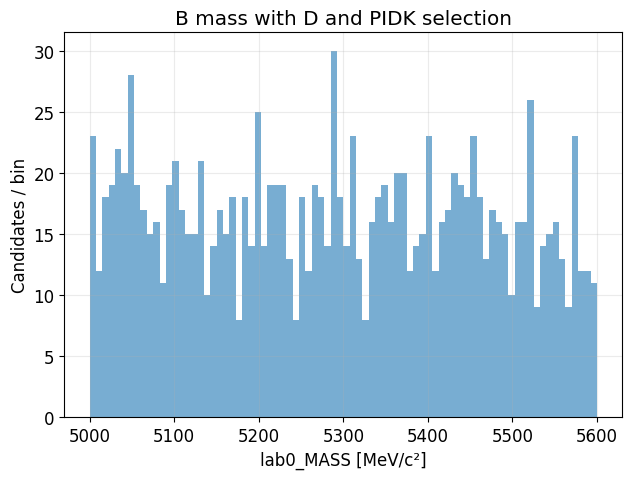

Candidates after cuts: 2189




In [21]:
mask = (pidk > 5) & (d_mass > 1820) & (d_mass < 1910)
plt.hist(b_mass[mask], bins=80, range=(5000, 5600), histtype='stepfilled', alpha=0.6)
plt.xlabel("lab0_MASS [MeV/c²]")
plt.ylabel("Candidates / bin")
plt.title("B mass with D and PIDK selection")
plt.show()
print(f"Candidates after cuts: {np.sum(mask)}")


In [2]:

import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.dpi"] = 130


In [3]:
# --- Input file and tree ---
file_path = "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2025/Bd2DK__up__2__final.root"
tree_name = "DecayTree"

# --- Branch names ---
bd_mass_branch = "Bd_M"
d_mass_branch  = "D_M"
xgb_branch     = "XGB"
pidk_branch    = "Bach_PIDK"

# --- Selection thresholds ---
xgb_threshold = 0.5
pidk_steps = [5, 10]

# --- Plot settings ---
bd_mass_range = (5100.0, 5600.0)
d_mass_range  = (1800.0, 1950.0)
bd_bins = 80
d_bins  = 75

# --- Output directory ---
outdir = Path("plots")
outdir.mkdir(parents=True, exist_ok=True)

print("Configuration ready.")


Configuration ready.




In [4]:
print(f"Opening: {file_path}")
f = uproot.open(file_path)

if tree_name not in f:
    raise KeyError(f"Tree '{tree_name}' not found. Available keys: {list(f.keys())[:10]}")

tree = f[tree_name]

required = [bd_mass_branch, d_mass_branch, xgb_branch, pidk_branch]
missing = [b for b in required if b not in tree.keys()]
if missing:
    print("Missing branches:", missing)
else:
    print("All required branches found")


Opening: /eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2025/Bd2DK__up__2__final.root




In [ ]:
arrays = tree.arrays(required, library="ak")

bd_m  = arrays[bd_mass_branch]
d_m   = arrays[d_mass_branch]
xgb   = arrays[xgb_branch]
pidk  = arrays[pidk_branch]

print(f"Loaded {len(xgb)} entries.")


In [ ]:
sel_xgb = xgb > xgb_threshold

counts = {
    "Total": len(xgb),
    f"XGB>{xgb_threshold}": int(ak.sum(sel_xgb))
}

sel_with_pidk = {}
for thr in pidk_steps:
    sel = sel_xgb & (pidk > thr)
    sel_with_pidk[thr] = sel
    counts[f"XGB>{xgb_threshold} & PIDK>{thr}"] = int(ak.sum(sel))

for k, v in counts.items():
    print(f"{k:>28}: {v}")


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

hist, edges = np.histogram(ak.to_numpy(d_m[sel_xgb]), bins=d_bins, range=d_mass_range)
centers = 0.5 * (edges[:-1] + edges[1:])
ax.step(centers, hist, where="mid", label=f"XGB>{xgb_threshold}", lw=1.5)

for thr in pidk_steps:
    h, e = np.histogram(ak.to_numpy(d_m[sel_with_pidk[thr]]), bins=d_bins, range=d_mass_range)
    c = 0.5 * (e[:-1] + e[1:])
    ax.step(c, h, where="mid", label=f"XGB>{xgb_threshold} & PIDK>{thr}", lw=1.5)

ax.set_xlabel("m(D) [MeV/c²]")
ax.set_ylabel("Entries / bin")
ax.set_title("D mass with XGB and PIDK cuts")
ax.legend()
ax.grid(True, alpha=0.3)

out_d = outdir / "D_mass_XGB_PIDK.png"
fig.tight_layout()
fig.savefig(out_d)
plt.show()

print(f"Saved → {out_d}")


In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 5))

hist, edges = np.histogram(ak.to_numpy(bd_m[sel_xgb]), bins=bd_bins, range=bd_mass_range)
centers = 0.5 * (edges[:-1] + edges[1:])
ax.step(centers, hist, where="mid", label=f"XGB>{xgb_threshold}", lw=1.5)

for thr in pidk_steps:
    h, e = np.histogram(ak.to_numpy(bd_m[sel_with_pidk[thr]]), bins=bd_bins, range=bd_mass_range)
    c = 0.5 * (e[:-1] + e[1:])
    ax.step(c, h, where="mid", label=f"XGB>{xgb_threshold} & PIDK>{thr}", lw=1.5)

ax.set_xlabel("m(Bd) [MeV/c²]")
ax.set_ylabel("Entries / bin")
ax.set_title("Bd mass with XGB and PIDK cuts")
ax.legend()
ax.grid(True, alpha=0.3)

out_bd = outdir / "Bd_mass_XGB_PIDK.png"
fig.tight_layout()
fig.savefig(out_bd)
plt.show()

print(f"Saved → {out_bd}")


In [5]:
# --- Base EOS directory (no filename here) ---
base_dir = "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2025"

# Common filename variants seen in shared links/messages (Slack often escapes underscores)
filename_candidates = [
    "Bd2DK__up__2__final.root",  # double underscores variant
    "Bd2DK_up_2_final.root",     # single underscores variant
]

# TTree name
tree_name = "DecayTree"

# Branch names
bd_mass_branch = "Bd_M"
d_mass_branch  = "D_M"
xgb_branch     = "XGB"
pidk_branch    = "Bach_PIDK"

# Selections
xgb_threshold = 0.5
pidk_steps = [5, 10]

# Plot ranges/bins
bd_mass_range = (5100.0, 5600.0)
d_mass_range  = (1800.0, 1950.0)
bd_bins = 80
d_bins  = 75

from pathlib import Path
outdir = Path("plots"); outdir.mkdir(parents=True, exist_ok=True)

print("Config ready. Will attempt local EOS and XRootD paths for each filename variant.")


Config ready. Will attempt local EOS and XRootD paths for each filename variant.




In [6]:

import uproot, os

tried = []
f = None
file_path_used = None

for fname in filename_candidates:
    # 1) Try local EOS mount
    local_path = f"{base_dir}/{fname}"
    tried.append(local_path)
    if os.path.exists(local_path):
        try:
            print(f"Trying local path: {local_path}")
            f = uproot.open(local_path)
            file_path_used = local_path
            break
        except Exception as e:
            print(f"Local open failed for {local_path}: {e}")

    # 2) Try XRootD
    xrd_path = f"root://eoslhcb.cern.ch//{base_dir.lstrip('/')}/{fname}"
    tried.append(xrd_path)
    try:
        print(f"Trying XRootD path: {xrd_path}")
        f = uproot.open(xrd_path)
        file_path_used = xrd_path
        break
    except Exception as e:
        print(f"XRootD open failed for {xrd_path}: {e}")

if f is None:
    print("\nCould not open the file. Paths tried (in order):")
    for p in tried:
        print("  -", p)
    raise FileNotFoundError("None of the candidate paths could be opened. Check mount/permissions/filename.")
else:
    print(f"\nOpened: {file_path_used}")

# Check the tree exists
if tree_name not in f:
    print("Available keys:", list(f.keys()))
    raise KeyError(f"Tree '{tree_name}' not found in file.")

tree = f[tree_name]

# Validate branches
required = [bd_mass_branch, d_mass_branch, xgb_branch, pidk_branch]
missing = [b for b in required if b not in tree.keys()]
if missing:
    preview = list(tree.keys())[:25]
    raise KeyError(f"Missing expected branches: {missing}\nAvailable branches (first 25): {preview}")
print("Tree and branches validated.")


Trying XRootD path: root://eoslhcb.cern.ch//eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2025/Bd2DK__up__2__final.root
XRootD open failed for root://eoslhcb.cern.ch//eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2025/Bd2DK__up__2__final.root: Failed to open file: [ERROR] Server responded with an error: [3011] Unable to open file /eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2025/Bd2DK__up__2__final.root; No such file or directory

Trying local path: /eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2025/Bd2DK_up_2_final.root

Opened: /eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2025/Bd2DK_up_2_final.root
Available keys: ['Tuple;1', 'Tuple/DecayTree;1']




In [9]:
import re

all_keys = list(tree.keys())
print(f"Total branches: {len(all_keys)}")

def match(pattern):
    rx = re.compile(pattern, re.I)
    return [k for k in all_keys if rx.search(k)]

# ---- Heuristics for typical LHCb ntuples ----
# Bd mass: prefer DTF-constrained mass of the B candidate (often lab0_* for the mother)
bd_candidates = []
bd_candidates += match(r"^(lab0_)?DTF.*MASS$")
bd_candidates += match(r"^(lab0_)?DTF_.*MASS$")
bd_candidates += match(r"^(lab0_)?END_?MASS$")
bd_candidates += match(r"^(lab0_)?MASS$")
bd_candidates += match(r"(^|_)Bd(_.*)?M(ASS|M)\b")
bd_candidates += match(r"(^|_)B(_.*)?M(ASS|M)\b")

# D mass: prefer the D daughter’s invariant mass (often lab1_* or lab2_*), or any *_D_*MASS/MM
d_candidates = []
d_candidates += match(r"^(lab[12]_)?DTF_.*D.*MASS$")
d_candidates += match(r"(^|_)D(_.*)?M(ASS|M)\b")
d_candidates += match(r"^(lab[12]_)?(END_)?MASS.*D")
d_candidates += match(r"^(lab[12]_)?MM$")

# XGB / MVA score: look for XGB, BDT, MVA
xgb_candidates = []
xgb_candidates += match(r"\bXGB(OOST)?\b")
xgb_candidates += match(r"\bXGBoost\b")
xgb_candidates += match(r"\bBDT(_?score)?\b")
xgb_candidates += match(r"\bMVA(_?score)?\b")

# Bachelor PIDK: look for PIDK, biasing towards bachelor or kaon track
pidk_candidates = []
pidk_candidates += match(r"(Bach|Bach[Kk]|K|kaon).*PIDK")
pidk_candidates += match(r"PIDK.*(Bach|Bach[Kk]|K|kaon)")
pidk_candidates += match(r"\bPIDK\b")
pidk_candidates = list(dict.fromkeys(pidk_candidates))  # unique preserve order

def pick(name, cands):
    seen = []
    for c in cands:
        if c not in seen:
            seen.append(c)
    print(f"\n{name} candidates (top 10 shown):")
    for i, k in enumerate(seen[:10]):
        print(f"  [{i}] {k}")
    return seen[0] if seen else None

bd_mass_branch  = pick("Bd mass", bd_candidates)
d_mass_branch   = pick("D mass",  d_candidates)
xgb_branch      = pick("XGB/MVA", xgb_candidates)
pidk_branch     = pick("PIDK",    pidk_candidates)

# Sanity fallback: if anything is still None, print a short inventory to help
missing = [("Bd mass", bd_mass_branch), ("D mass", d_mass_branch),
           ("XGB/MVA", xgb_branch), ("PIDK", pidk_branch)]
missing = [n for n, v in missing if v is None]
if missing:
    print("\nCould not auto-detect:", ", ".join(missing))
    print("Filters that may help find them manually:")
    print("  MASS-like:", [k for k in all_keys if k.endswith('MASS')][:10])
    print("  *_MM:", [k for k in all_keys if k.endswith('_MM')][:10])
    print("  PIDK:", [k for k in all_keys if 'PIDK' in k][:10])
    print("  MVA:", [k for k in all_keys if re.search(r'XGB|BDT|MVA', k, re.I)][:10])

# Final confirmation
print("\nUsing:")
print("  Bd mass branch :", bd_mass_branch)
print("  D mass branch  :", d_mass_branch)
print("  XGB branch     :", xgb_branch)
print("  PIDK branch    :", pidk_branch)



Total branches: 292

Bd mass candidates (top 10 shown):
  [0] lab0_DTF_LifetimeFit_MASS
  [1] lab0_DTF_MassFitConsD_MASS
  [2] lab0_MASS

D mass candidates (top 10 shown):
  [0] lab2_MassHypo_Lambda_pi1
  [1] lab2_MassHypo_Lambda_pi2
  [2] lab2_MassHypo_Ds_pi1
  [3] lab2_MassHypo_Ds_pi2
  [4] lab2_MM

XGB/MVA candidates (top 10 shown):

PIDK candidates (top 10 shown):

Could not auto-detect: XGB/MVA, PIDK
Filters that may help find them manually:
  MASS-like: ['lab0_DTF_LifetimeFit_MASS', 'lab0_DTF_MassFitConsD_MASS', 'lab0_MASS', 'lab1_MASS', 'lab2_MASS', 'lab3_MASS', 'lab4_MASS', 'lab5_MASS']
  *_MM: ['lab0_MM', 'lab2_MM', 'lab34_MM', 'lab13_MM', 'lab14_MM', 'lab134_MM', 'lab45_MM', 'lab35_MM', 'lab15_MM', 'lab135_MM']
  PIDK: ['lab1_PIDK', 'lab3_PIDK', 'lab4_PIDK', 'lab5_PIDK']
  MVA: ['Hlt1TrackMVADecision', 'Hlt1TwoTrackMVADecision', 'Hlt2B2OC_BdToDmK_DmToPimPimKpDecision', 'lab0_Hlt1TrackMVADecision_TIS', 'lab0_Hlt1TrackMVADecision_TOS', 'lab0_Hlt1TwoTrackMVADecision_TIS', 'lab0_

In [10]:
# List every branch in the tree
all_branches = list(tree.keys())

print(f"Total branches: {len(all_branches)}")
for i, name in enumerate(all_branches):
    print(f"[{i:03}] {name}")


Total branches: 292
[000] EVENTNUMBER
[001] Hlt1TrackMVADecision
[002] Hlt1TwoTrackMVADecision
[003] Hlt1_TCK
[004] Hlt2B2OC_BdToDmK_DmToPimPimKpDecision
[005] Hlt2Topo2BodyDecision
[006] Hlt2Topo3BodyDecision
[007] Hlt2_TCK
[008] RUNNUMBER
[009] lab0_BPVCHI2DOF
[010] lab0_BPVDIRA
[011] lab0_BPVFD
[012] lab0_BPVFDCHI2
[013] lab0_BPVIP
[014] lab0_BPVIPCHI2
[015] lab0_BPVLTIME
[016] lab0_BPVX
[017] lab0_BPVY
[018] lab0_BPVZ
[019] lab0_CHI2DOF
[020] lab0_CHILD1_FDCHI2wrtSV
[021] lab0_CHILD1_FDwrtSV
[022] lab0_CHILD1_IPCHI2wrtSV
[023] lab0_CHILD1_IPwrtSV
[024] lab0_DTF_LifetimeFit_CHI2DOF
[025] lab0_DTF_LifetimeFit_CTAU
[026] lab0_DTF_LifetimeFit_CTAUERR
[027] lab0_DTF_LifetimeFit_MASS
[028] lab0_DTF_MassFitConsD_CHI2DOF
[029] lab0_DTF_MassFitConsD_MASS
[030] lab0_DTF_MassFitConsD_P
[031] lab0_END_VCHI2DOF
[032] lab0_END_VX
[033] lab0_END_VY
[034] lab0_END_VZ
[035] lab0_ETA
[036] lab0_Hlt1TrackMVADecision_TIS
[037] lab0_Hlt1TrackMVADecision_TOS
[038] lab0_Hlt1TwoTrackMVADecision_TIS
[039] 

[i] Opening: /eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2025/Bd2DK_up_2_final.root
[i] Using tree: Tuple/DecayTree
[i] Selected branches:
    XGB            : BDTGResponse_XGB_1
    Bd mass        : lab0_DTF_LifetimeFit_MASS
    D mass         : lab2_MM
    Bachelor PIDK  : lab3_PIDK
[i] Reading branches: lab0_DTF_LifetimeFit_MASS, lab2_MM, BDTGResponse_XGB_1, lab3_PIDK
[i] Loaded 490877 events.
[i] Counts:
    Total                : 490877
    XGB>0.5         : 490877
    XGB>0.5 & PIDK>5  : 403485
    XGB>0.5 & PIDK>10 : 368202




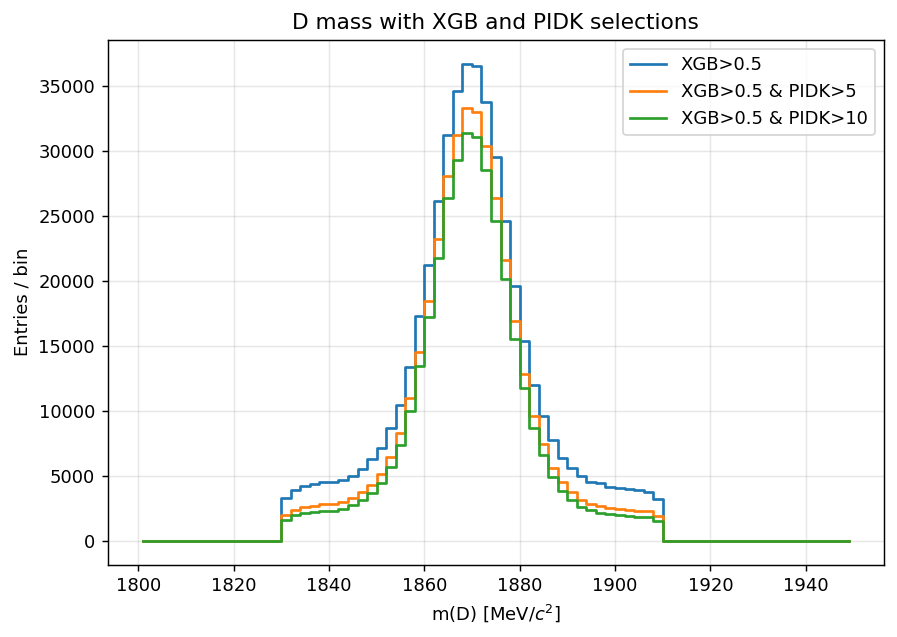

Saved: plots/D_mass_XGB_PIDK.png




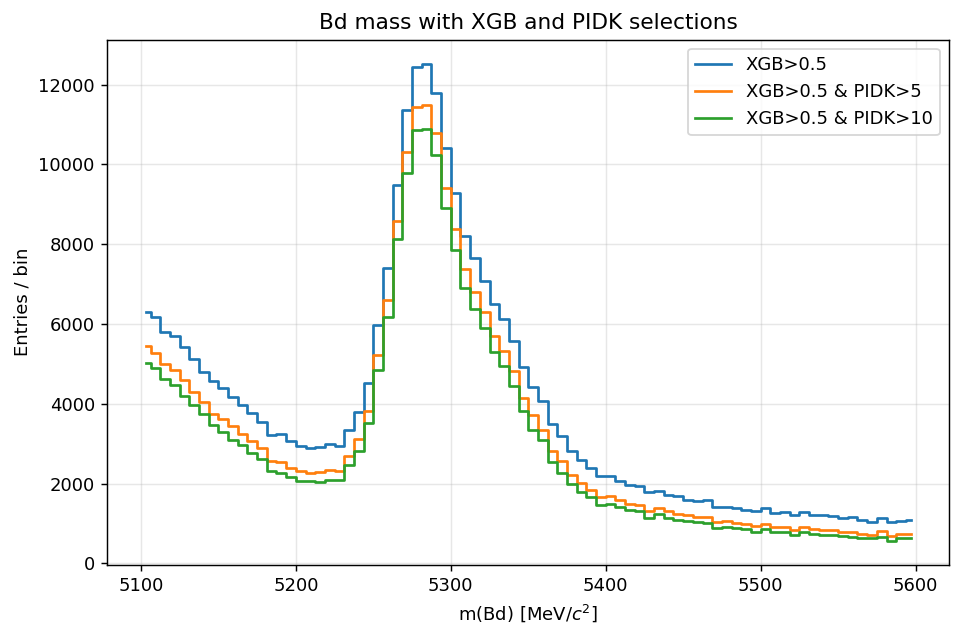

Saved: plots/Bd_mass_XGB_PIDK.png




In [11]:

import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import uproot
import awkward as ak

# ----------------------- Configuration -----------------------
base_dir = "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2025"
root_file = "Bd2DK_up_2_final.root"
file_path = f"{base_dir}/{root_file}"

# Selections
xgb_threshold = 0.5
pidk_steps = [5, 10]

# Plot ranges & binning
bd_mass_range = (5100.0, 5600.0)
d_mass_range  = (1800.0, 1950.0)
bd_bins = 80
d_bins  = 75

# Output dir
outdir = Path("plots"); outdir.mkdir(parents=True, exist_ok=True)
plt.rcParams["figure.dpi"] = 130

# ----------------------- Helpers -----------------------
def autodetect_tree(file_handle):
    """Find a TTree that ends with 'DecayTree' (e.g. 'Tuple/DecayTree').
    If none found, return the only TTree present (if unique)."""
    classmap = file_handle.classnames()  # key -> class name
    tt_keys = [k.split(";")[0] for k, cls in classmap.items() if "TTree" in cls]
    for k in tt_keys:
        if k.endswith("/DecayTree") or k.endswith("DecayTree"):
            return k
    if len(tt_keys) == 1:
        return tt_keys[0]
    raise KeyError(f"Could not find a DecayTree. Trees found: {tt_keys}")

def choose_first_present(candidates, keys):
    """Return the first candidate present in keys, else None."""
    for c in candidates:
        if c in keys:
            return c
    return None

def step_hist(ax, data, bins, rng, label, lw=1.5):
    hist, edges = np.histogram(ak.to_numpy(data), bins=bins, range=rng)
    centers = 0.5 * (edges[:-1] + edges[1:])
    ax.step(centers, hist, where="mid", lw=lw, label=label)

# ----------------------- Open file & tree -----------------------
print(f"[i] Opening: {file_path}")
if not os.path.exists(file_path):
    raise FileNotFoundError(f"File not found: {file_path}")

f = uproot.open(file_path)
tree_key = autodetect_tree(f)
tree = f[tree_key]
print(f"[i] Using tree: {tree_key}")

# ----------------------- Pick branches -----------------------
# XGB classifier response
xgb_branch = "BDTGResponse_XGB_1"

# Bd mass: prefer DTF mass, then other sensible fallbacks
bd_mass_candidates = [
    "lab0_DTF_LifetimeFit_MASS",
    "lab0_DTF_MassFitConsD_MASS",
    "lab0_MM",
    "lab0_MASS",
]
bd_mass_branch = choose_first_present(bd_mass_candidates, tree.keys())

# D candidate mass (lab2)
d_mass_candidates = ["lab2_MM", "lab2_MASS"]
d_mass_branch = choose_first_present(d_mass_candidates, tree.keys())

# Bachelor PIDK: try K bachelor first (3), then 4, 5, then 1
pidk_candidates = ["lab3_PIDK", "lab4_PIDK", "lab5_PIDK", "lab1_PIDK"]
pidk_branch = choose_first_present(pidk_candidates, tree.keys())

print("[i] Selected branches:")
print(f"    XGB            : {xgb_branch}")
print(f"    Bd mass        : {bd_mass_branch}")
print(f"    D mass         : {d_mass_branch}")
print(f"    Bachelor PIDK  : {pidk_branch}")

missing = [name for name, val in {
    "XGB": xgb_branch, "Bd mass": bd_mass_branch,
    "D mass": d_mass_branch, "PIDK": pidk_branch
}.items() if val is None]
if missing:
    raise KeyError(f"Missing required mappings for: {missing}. "
                   "The branch names above may need adjusting for a different ntuple.")

# ----------------------- Read arrays -----------------------
branches = [bd_mass_branch, d_mass_branch, xgb_branch, pidk_branch]
print("[i] Reading branches:", ", ".join(branches))
arr = tree.arrays(branches, library="ak")

bd_m = arr[bd_mass_branch]
d_m  = arr[d_mass_branch]
xgb  = arr[xgb_branch]
pidk = arr[pidk_branch]

print(f"[i] Loaded {len(xgb)} events.")

# ----------------------- Selections -----------------------
sel_xgb = xgb > xgb_threshold
sel_pidk = {thr: (sel_xgb & (pidk > thr)) for thr in pidk_steps}

print("[i] Counts:")
print(f"    Total                : {len(xgb)}")
print(f"    XGB>{xgb_threshold:<5}       : {int(ak.sum(sel_xgb))}")
for thr in pidk_steps:
    print(f"    XGB>{xgb_threshold} & PIDK>{thr:<2} : {int(ak.sum(sel_pidk[thr]))}")

# ----------------------- Plot: D mass -----------------------
fig, ax = plt.subplots(figsize=(7, 5))
step_hist(ax, d_m[sel_xgb], d_bins, d_mass_range, label=f"XGB>{xgb_threshold}")
for thr in pidk_steps:
    step_hist(ax, d_m[sel_pidk[thr]], d_bins, d_mass_range, label=f"XGB>{xgb_threshold} & PIDK>{thr}")
ax.set_xlabel("m(D) [MeV/$c^2$]")
ax.set_ylabel("Entries / bin")
ax.set_title("D mass with XGB and PIDK selections")
ax.grid(True, alpha=0.3)
ax.legend()
d_out = outdir / "D_mass_XGB_PIDK.png"
fig.tight_layout(); fig.savefig(d_out)
plt.show()
print(f"Saved: {d_out}")

# ----------------------- Plot: Bd mass -----------------------
fig, ax = plt.subplots(figsize=(7.5, 5))
step_hist(ax, bd_m[sel_xgb], bd_bins, bd_mass_range, label=f"XGB>{xgb_threshold}")
for thr in pidk_steps:
    step_hist(ax, bd_m[sel_pidk[thr]], bd_bins, bd_mass_range, label=f"XGB>{xgb_threshold} & PIDK>{thr}")
ax.set_xlabel("m(Bd) [MeV/$c^2$]")
ax.set_ylabel("Entries / bin")
ax.set_title("Bd mass with XGB and PIDK selections")
ax.grid(True, alpha=0.3)
ax.legend()
b_out = outdir / "Bd_mass_XGB_PIDK.png"
fig.tight_layout(); fig.savefig(b_out)
plt.show()
print(f"Saved: {b_out}")

# ----------------------- (Optional) Inspect XGB spectrum -----------------------
# Uncomment to quickly see how the XGB score looks overall and with the cut.
# fig, ax = plt.subplots(figsize=(6.5, 4.5))
# h, e = np.histogram(ak.to_numpy(xgb), bins=60, range=(0.0, 1.0))
# c = 0.5 * (e[:-1] + e[1:])
# ax.step(c, h, where="mid", lw=1.5, label="All")
# h2, e2 = np.histogram(ak.to_numpy(xgb[sel_xgb]), bins=60, range=(0.0, 1.0))
# c2 = 0.5 * (e2[:-1] + e2[1:])
# ax.step(c2, h2, where="mid", lw=1.5, label=f"XGB>{xgb_threshold}")
# ax.set_xlabel("XGB score"); ax.set_ylabel("Entries / bin")
# ax.set_title("XGB distribution"); ax.grid(True, alpha=0.3); ax.legend(); plt.show()
